# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

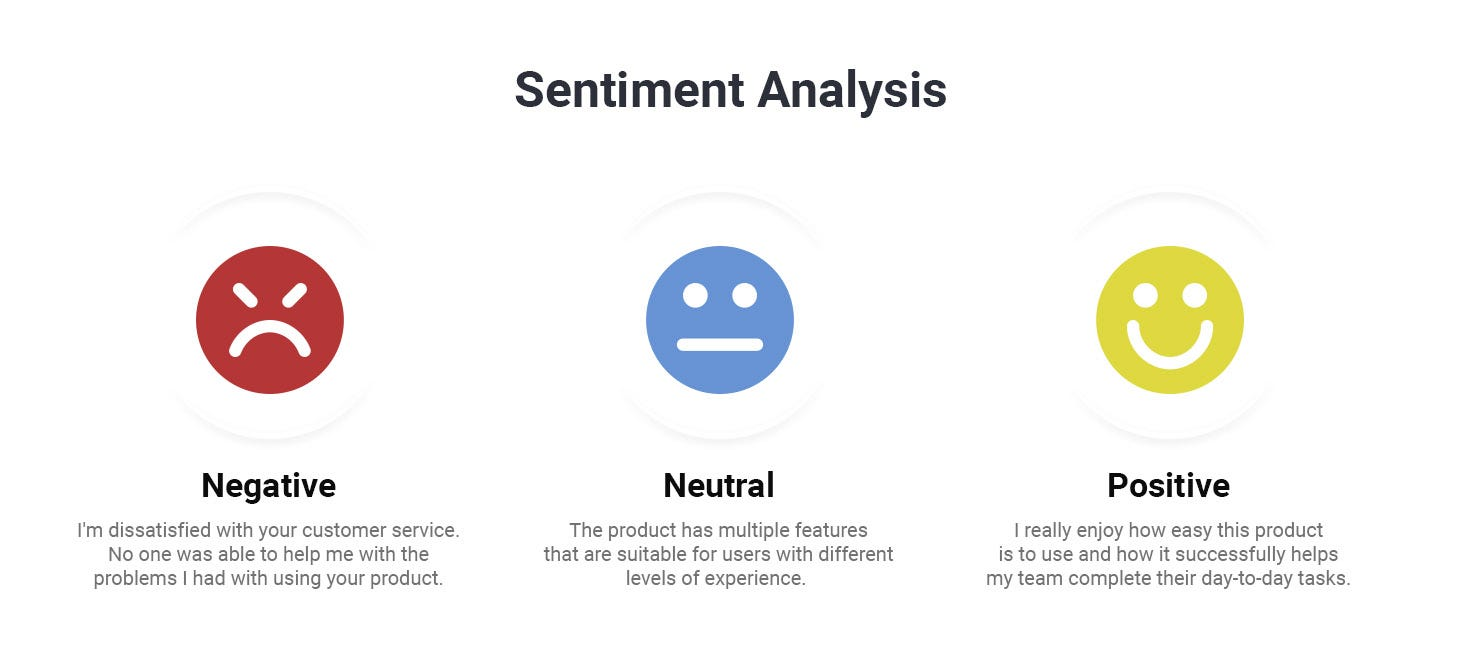

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Branch: location of Disneyland Park

Download the CSV file from the Kaggle link above and put it in the same folder as this notebook (or upload it to Colab), so the file name in the next cell matches.

In [1]:
# Load the dataset
import pandas as pd

data = pd.read_csv('DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [2]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [3]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [4]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [5]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [7]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.59       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.97      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

### Solution

Download `Amazon_Unlocked_Mobile.csv` from the Kaggle link above and put it in the same folder as this notebook (or upload it to Colab).

### Task 1: Load the data and do 5 different preprocessing steps

In [9]:
# Load the dataset
import re
import html
from functools import lru_cache

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

phones = pd.read_csv('Amazon_Unlocked_Mobile.csv')
print("Original shape:", phones.shape)
phones.head()

Original shape: (413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [10]:
# Preprocessing step 1: handle missing values
print(phones.isna().sum())

# We only need the review text and the rating, so we drop rows where one of them is missing
phones = phones.dropna(subset=['Reviews', 'Rating'])

# Map star ratings to sentiments (same as the Disneyland example)
phones['Sentiment'] = phones['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
phones['Sentiment'].value_counts()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64


Sentiment
positive    284948
negative     97059
neutral      31763
Name: count, dtype: int64

In [11]:
# Preprocessing steps 2-5

# Keep the negation words: removing "not" from "not good" would flip the meaning of the review
stop_words = set(stopwords.words('english')) - {'no', 'nor', 'not'}

lemmatizer = WordNetLemmatizer()

@lru_cache(maxsize=None)          # the same words repeat a lot, so cache the lemmas to make it fast
def lemmatize(word):
    return lemmatizer.lemmatize(word)

def preprocess_review(text):
    # 2. Convert text to lowercase
    text = text.lower()

    # 3. Remove noise: HTML entities and tags, links, apostrophes, digits, punctuation and special characters
    text = html.unescape(text)                            # &amp; -> &
    text = re.sub(r'<[^>]+>', ' ', text)                  # HTML tags such as <br />
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)    # links
    text = re.sub(r"['\u2019]", '', text)                 # don't -> dont
    text = re.sub(r'[^a-z\s]', ' ', text)                 # everything that is not a letter

    # 4. Remove stop words
    words = [word for word in text.split() if word not in stop_words]

    # 5. Lemmatization (phones -> phone)
    words = [lemmatize(word) for word in words]

    return ' '.join(words)

phones['Clean_Review'] = phones['Reviews'].astype(str).apply(preprocess_review)

# Some reviews become empty after cleaning (for example a review that was only "!!!"), so we remove them
phones = phones[phones['Clean_Review'] != '']
print("Shape after preprocessing:", phones.shape)

pd.set_option('display.max_colwidth', 80)
phones[['Reviews', 'Clean_Review', 'Sentiment']].head()

Shape after preprocessing: (412722, 8)


,Reviews,Clean_Review,Sentiment
0,I feel so LUCKY to have found this used (phone to us & not used hard at all)...,feel lucky found used phone u not used hard phone line someone upgraded sold...,positive
1,"nice phone, nice up grade from my pantach revue. Very clean set up and easy ...",nice phone nice grade pantach revue clean set easy set never android phone f...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but its a very good phone I love it,work good go slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only thing is the volume up button...,great phone replace lost phone thing volume button not work still go setting...,positive


### Task 2: Use a proper train and test split

In [12]:
from sklearn.model_selection import train_test_split

# stratify keeps the same percentage of positive / neutral / negative reviews in both sets
# (important here because the classes are imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    phones['Clean_Review'], phones['Sentiment'],
    test_size=0.2, random_state=42, stratify=phones['Sentiment'])

print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")
print()
print("Sentiment percentages in the training set:")
print(y_train.value_counts(normalize=True).round(3))

X_train size: (330177,)
X_test size: (82545,)

Sentiment percentages in the training set:
Sentiment
positive    0.688
negative    0.235
neutral     0.077
Name: proportion, dtype: float64


### Task 3: Do Feature Extraction Using TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Unigrams + bigrams (so "not good" is a feature of its own), limited to the 10000 most frequent ones
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Learn the vocabulary and the IDF values from the training set only, then transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)

Train matrix shape: (330177, 10000)
Test matrix shape: (82545, 10000)


### Task 4: Train a Naive Bayes Classifier

In [14]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Task 5: Evaluate the model on the Test Set

In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions on the test set
nb_predictions = nb_classifier.predict(X_test_tfidf)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, nb_predictions):.2f}")

print("Classification Report:")
print(classification_report(y_test, nb_predictions, zero_division=0))

Accuracy: 0.86
Classification Report:


              precision    recall  f1-score   support

    negative       0.80      0.83      0.81     19403
     neutral       0.43      0.10      0.17      6347
    positive       0.89      0.96      0.93     56795

    accuracy                           0.86     82545
   macro avg       0.71      0.63      0.64     82545
weighted avg       0.84      0.86      0.84     82545



### Task 6: Print the Confusion Matrix

                 predicted negative  predicted neutral  predicted positive
actual negative               16020                319                3064
actual neutral                 2219                659                3469
actual positive                1699                540               54556


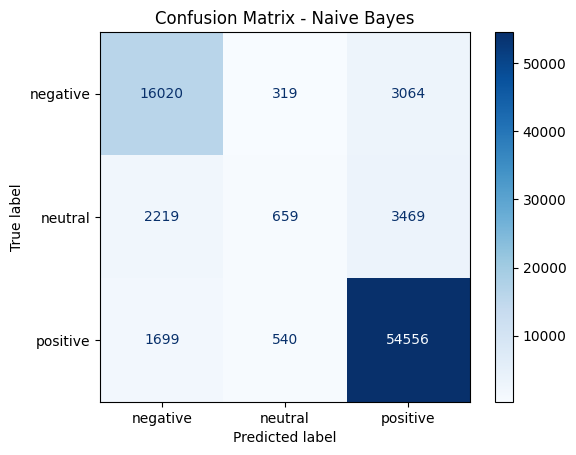

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, nb_predictions, labels=labels)

# Rows = actual sentiment, columns = predicted sentiment
print(pd.DataFrame(cm, index=[f'actual {l}' for l in labels], columns=[f'predicted {l}' for l in labels]))

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()